In [83]:
from database.adatabase import ADatabase
from processor.processor import Processor as processor
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")

In [84]:
market = ADatabase("market")

In [85]:
market.connect()
russell1000 = market.retrieve("russell1000")
market.disconnect()

In [86]:
market.connect()
analysis = []
for ticker in tqdm(russell1000["ticker"].values):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","ticker","adjclose"]]
        analysis.append({
            "ticker":ticker,
            "coefficient_of_variance": ticker_prices["adjclose"].std() / ticker_prices["adjclose"].mean(),
            "return":(ticker_prices["adjclose"].iloc[-1] - ticker_prices["adjclose"].iloc[0]) / ticker_prices["adjclose"].iloc[0]
        })
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1009/1009 [04:31<00:00,  3.72it/s]


In [87]:
a = pd.DataFrame(analysis)
a["covr"] = a["return"] / a["coefficient_of_variance"]

In [88]:
factors = a.sort_values("covr",ascending=True).iloc[:10]["ticker"]

In [89]:
market.connect()
factor_dfs = []
for ticker in factors:
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","ticker","adjclose"]]
        factor_dfs.append(ticker_prices)
    except:
        print(ticker)
        continue
factor_df = pd.concat(factor_dfs).pivot_table(index="date",columns="ticker",values="adjclose").reset_index()

In [90]:
factor_df

ticker,date,APTV,AWK,CHH,EXC,G,MTN,PAYC,QDEL,SAM,TROW
0,2022-01-03 05:00:00+00:00,166.03,184.14,154.00,57.07,53.00,321.97,404.94,134.29,520.20,194.58
1,2022-01-04 05:00:00+00:00,172.21,179.42,154.62,57.01,53.57,317.36,391.87,126.16,508.17,195.12
2,2022-01-05 05:00:00+00:00,168.28,178.10,150.92,56.97,52.26,308.19,360.94,126.80,502.22,187.48
3,2022-01-06 05:00:00+00:00,174.12,175.30,154.57,56.73,52.40,315.08,356.83,126.89,499.33,190.02
4,2022-01-07 05:00:00+00:00,169.47,173.50,154.27,56.64,52.28,308.12,355.80,124.10,516.88,191.58
...,...,...,...,...,...,...,...,...,...,...,...
496,2023-12-22 05:00:00+00:00,89.02,131.56,114.07,35.26,34.59,222.35,205.60,73.98,350.07,107.89
497,2023-12-26 05:00:00+00:00,89.44,132.27,113.26,35.53,34.62,220.89,206.32,75.32,350.54,108.69
498,2023-12-27 05:00:00+00:00,89.63,132.23,113.04,35.41,34.54,217.32,205.69,75.44,348.74,108.69
499,2023-12-28 05:00:00+00:00,90.47,132.98,112.95,35.85,34.61,218.23,207.56,75.03,349.30,109.01


In [95]:
market.connect()
sim = []
for ticker in tqdm(russell1000["ticker"].values):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","weekday","ticker","adjclose"]]
        ticker_prices = processor.merge(ticker_prices,factor_df.copy(),on="date")
        training_data = ticker_prices.iloc[:100]
        simulation_data = ticker_prices.iloc[100:]
        for factor in factors:
            covariance = training_data["adjclose"].cov(training_data[factor])
            simulation_data[f"{factor}_beta"] = covariance / simulation_data[factor].rolling(100).var()
            simulation_data[f"{factor}_loading"] = simulation_data[factor] * simulation_data[f"{factor}_beta"]
        simulation_data["expected_value"] = [sum([row[1][f"{factor}_loading"] for factor in factors]) for row in simulation_data.iterrows()]
        simulation_data["return"] = (simulation_data["adjclose"].shift(-5) - simulation_data["adjclose"].shift(-1)) / simulation_data["adjclose"].shift(-1)
        sim.append(simulation_data[["date","weekday","ticker","expected_value","return"]])
    except Exception as e:
        print(str(e))
market.disconnect()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1009/1009 [22:29<00:00,  1.34s/it]


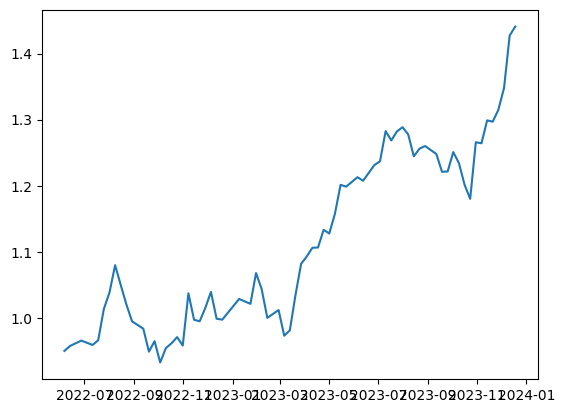

In [96]:
positions = 10 
simulation = pd.concat(sim)
trades = simulation[simulation["weekday"]==0]
trades["return"] = trades["return"] * 0.1
trades["return"] = [max(-.005,x) for x in trades["return"]]
trades = trades.sort_values("expected_value",ascending=False).groupby("date").nth([i for i in range(positions)])
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.show()